# SE(3) 轨迹Flow Matching过拟合测试

## 📋 概述

本notebook对单条倒水轨迹（`1_water_200.pkl`）进行**Flow Matching过拟合测试**。

### 🎯 任务目标
1. **数据预处理**：对比两种SE(3)轨迹表示方法（9D绝对位姿 vs ΔSE(3)增量）
2. **重构验证**：通过数值和可视化评估预处理管线的正确性
3. **Flow Matching训练**：使用**fmtorch库**和**torchdiffeq**进行过拟合训练
4. **超参数扫描**：15-20组配置（网络大小、学习率调度、初始学习率）

### 🔧 技术栈
- **Flow Matching基础设施**：严格对齐`Car_FM_SingleStep_enhanced.ipynb`
  - `fmtorch.path.AffinePath` + `fmtorch.scheduler.CondOTScheduler`
  - `fmtorch.utils.ModelWrapper`（网络基类）
  - `torchdiffeq.odeint`（ODE求解）
- **网络架构**：CBAM Attention + 多残差Transformer块（比single-step car更大）
- **数据表示**：ΔSE(3)（方法2，6D增量：3D旋转ω + 3D平移v）

### 📂 输出结果
- `artifacts/pouring_overfit_single/`：所有中间结果和最终模型
- 最佳模型权重：`best_model_sweep_X.pt`
- 训练曲线、重构误差、可视化对比图

### 🚀 使用方法
按顺序运行所有cells即可。主要步骤：
1. **Cells 1-20**：数据加载和预处理
2. **Cells 21-40**：重构验证和误差分析
3. **Cells 41-50**：可视化对比
4. **Cells 51-70**：Flow Matching训练（超参数扫描）
5. **Cells 71-80**：推理和最终评估

---


In [43]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import os
import json
from pathlib import Path
import sys

# 添加visualizer路径
sys.path.append(os.path.dirname(os.path.abspath('')))

print("导入成功！")

导入成功！


## 1. 加载原始轨迹数据

In [44]:
# 数据路径
pkl_path = '../MMLfD-Tutorial_Modified/datasets/pouring_data/1_water_200.pkl'
artifacts_dir = Path('./artifacts/pouring_overfit_single')
artifacts_dir.mkdir(parents=True, exist_ok=True)

# 加载pkl文件
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

print(f"数据键: {data.keys()}")
print(f"轨迹形状: {data['traj'].shape}")
print(f"瓶子索引: {data.get('bottle_idx', 'N/A')}")
print(f"杯子索引: {data.get('mug_idx', 'N/A')}")

# 提取轨迹 (480, 4, 4)
T_seq_raw = data['traj']
num_frames = T_seq_raw.shape[0]
print(f"\n总帧数: {num_frames}")

数据键: dict_keys(['traj', 'bottle_idx', 'mug_idx', 'offset', 'radius', 'height', 'label', 'text'])
轨迹形状: (480, 4, 4)
瓶子索引: 1
杯子索引: 4

总帧数: 480


/tmp/ipykernel_1105632/70748734.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


## 2. 工具函数：SO(3)投影与SE(3)李代数

In [45]:
def project_to_SO3(R_mat):
    """通过SVD将3x3矩阵投影到SO(3)"""
    U, _, Vt = np.linalg.svd(R_mat)
    S = np.eye(3)
    S[2, 2] = np.linalg.det(U @ Vt)
    return U @ S @ Vt

def project_to_SO3_batch(R_batch):
    """批量投影到SO(3)"""
    return np.array([project_to_SO3(R) for R in R_batch])

def se3_log(T):
    """SE(3)的对数映射: T -> ξ ∈ R^6 [ω(3), v(3)]"""
    R_mat = T[:3, :3]
    t = T[:3, 3]
    
    # 使用scipy计算旋转向量
    rot = R.from_matrix(R_mat)
    omega = rot.as_rotvec()  # 3D rotation vector
    
    theta = np.linalg.norm(omega)
    
    if theta < 1e-8:
        # 接近单位矩阵
        V_inv = np.eye(3)
    else:
        omega_hat = omega / theta
        omega_hat_skew = np.array([
            [0, -omega_hat[2], omega_hat[1]],
            [omega_hat[2], 0, -omega_hat[0]],
            [-omega_hat[1], omega_hat[0], 0]
        ])
        
        # V矩阵的逆
        V_inv = (np.eye(3) - 0.5 * theta * omega_hat_skew + 
                 (1 - theta / (2 * np.tan(theta / 2))) * (omega_hat_skew @ omega_hat_skew))
    
    v = V_inv @ t
    
    return np.concatenate([omega, v])  # [ω(3), v(3)]

def se3_exp(xi):
    """SE(3)的指数映射: ξ ∈ R^6 -> T ∈ SE(3)"""
    omega = xi[:3]
    v = xi[3:]
    
    theta = np.linalg.norm(omega)
    
    if theta < 1e-8:
        # 接近零旋转
        R_mat = np.eye(3)
        V = np.eye(3)
    else:
        # Rodrigues公式
        rot = R.from_rotvec(omega)
        R_mat = rot.as_matrix()
        
        omega_hat = omega / theta
        omega_hat_skew = np.array([
            [0, -omega_hat[2], omega_hat[1]],
            [omega_hat[2], 0, -omega_hat[0]],
            [-omega_hat[1], omega_hat[0], 0]
        ])
        
        # V矩阵
        V = (np.eye(3) + 
             (1 - np.cos(theta)) / theta * omega_hat_skew + 
             (theta - np.sin(theta)) / theta * (omega_hat_skew @ omega_hat_skew))
    
    t = V @ v
    
    T = np.eye(4)
    T[:3, :3] = R_mat
    T[:3, 3] = t
    
    return T

def rotation_geodesic_distance(R1, R2):
    """计算两个旋转矩阵之间的测地距离（度数）"""
    R_diff = R1.T @ R2
    trace = np.trace(R_diff)
    # 数值稳定性
    cos_angle = np.clip((trace - 1) / 2, -1.0, 1.0)
    angle_rad = np.arccos(cos_angle)
    return np.degrees(angle_rad)

print("工具函数定义完成！")

工具函数定义完成！


## 3. 方法1: R9+t3 绝对位姿表示

In [46]:
# ============== 预处理 ==============
print("方法1: R9+t3 预处理...")

# Step 1: 提取旋转和平移
R_seq = T_seq_raw[:, :3, :3].copy()
t_seq = T_seq_raw[:, :3, 3].copy()

# Step 2: SO(3)投影
R_seq_clean = project_to_SO3_batch(R_seq)

# Step 3: 对齐到首帧（可选，建议启用）
T_0 = np.eye(4)
T_0[:3, :3] = R_seq_clean[0]
T_0[:3, 3] = t_seq[0]
T_0_inv = np.linalg.inv(T_0)

# 对齐
T_seq_aligned = np.zeros_like(T_seq_raw)
for k in range(num_frames):
    T_k = np.eye(4)
    T_k[:3, :3] = R_seq_clean[k]
    T_k[:3, 3] = t_seq[k]
    T_seq_aligned[k] = T_0_inv @ T_k

R_seq_aligned = T_seq_aligned[:, :3, :3]
t_seq_aligned = T_seq_aligned[:, :3, 3]

# Step 4: 展开为R9+t3
r9_seq = R_seq_aligned.reshape(num_frames, 9)  # 按行展开
X_abs = np.concatenate([r9_seq, t_seq_aligned], axis=1)  # (480, 12)

# Step 5: 白化（分通道统计）
mu_R9 = r9_seq.mean(axis=0)
sigma_R9 = r9_seq.std(axis=0) + 1e-8
mu_t3 = t_seq_aligned.mean(axis=0)
sigma_t3 = t_seq_aligned.std(axis=0) + 1e-8

Z_abs = np.zeros_like(X_abs)
Z_abs[:, :9] = (r9_seq - mu_R9) / sigma_R9
Z_abs[:, 9:12] = (t_seq_aligned - mu_t3) / sigma_t3

# 保存
np.savez(artifacts_dir / '02_abs_R9_t3_seq.npz',
         Z_abs=Z_abs,
         mask=np.ones(num_frames),
         aligned_to_T0=True)

whitening_stats_abs = {
    'mu_R9': mu_R9.tolist(),
    'sigma_R9': sigma_R9.tolist(),
    'mu_t3': mu_t3.tolist(),
    'sigma_t3': sigma_t3.tolist()
}
with open(artifacts_dir / '04_whiten_abs.json', 'w') as f:
    json.dump(whitening_stats_abs, f, indent=2)

# 保存T_0用于恢复
np.save(artifacts_dir / 'T_0.npy', T_0)

print(f"Z_abs shape: {Z_abs.shape}")
print(f"白化后统计: mean={Z_abs.mean():.6f}, std={Z_abs.std():.6f}")
print(f"保存到: {artifacts_dir}")

方法1: R9+t3 预处理...
Z_abs shape: (480, 12)
白化后统计: mean=-0.000000, std=1.000000
保存到: artifacts/pouring_overfit_single


In [47]:
def build_local_mask(L, w, device):
    """Builds a local attention mask for a sequence of length L with window size w."""
    mask = torch.full((L, L), float('-inf'), device=device)
    i = torch.arange(L, device=device)
    dist = (i[None, :] - i[:, None]).abs()
    mask[dist <= w] = 0.0
    return mask


In [48]:
# ============== 重构测试 ==============
print("\n方法1: R9+t3 重构测试...")

# Step 1: 反白化
r9_recon = Z_abs[:, :9] * sigma_R9 + mu_R9
t_recon = Z_abs[:, 9:12] * sigma_t3 + mu_t3

# Step 2: 重塑并投影到SO(3)
R_recon_aligned = r9_recon.reshape(num_frames, 3, 3)
R_recon_aligned = project_to_SO3_batch(R_recon_aligned)

# Step 3: 恢复绝对位姿
T_recon_abs = np.zeros((num_frames, 4, 4))
for k in range(num_frames):
    T_aligned = np.eye(4)
    T_aligned[:3, :3] = R_recon_aligned[k]
    T_aligned[:3, 3] = t_recon[k]
    T_recon_abs[k] = T_0 @ T_aligned

# 保存重构结果
np.savez(artifacts_dir / '21_recon_abs_T_seq.npz',
         T_hat=T_recon_abs)

print("重构完成！")


方法1: R9+t3 重构测试...
重构完成！


## 4. 方法2: ΔSE(3) 增量表示

In [49]:
# ============== 预处理 ==============
print("方法2: ΔSE(3) 预处理...")

# 使用已对齐的轨迹
T_seq_for_delta = T_seq_aligned.copy()

# Step 1: 计算相邻帧增量
delta_xi_seq = []
for k in range(1, num_frames):
    T_prev_inv = np.linalg.inv(T_seq_for_delta[k-1])
    delta_T = T_prev_inv @ T_seq_for_delta[k]
    xi = se3_log(delta_T)
    delta_xi_seq.append(xi)

delta_xi_seq = np.array(delta_xi_seq)  # (479, 6)

# Step 2: 白化（分旋转和平移）
omega_seq = delta_xi_seq[:, :3]
v_seq = delta_xi_seq[:, 3:]

mu_omega = omega_seq.mean(axis=0)
sigma_omega = omega_seq.std(axis=0) + 1e-8
mu_v = v_seq.mean(axis=0)
sigma_v = v_seq.std(axis=0) + 1e-8

Z_delta = np.zeros_like(delta_xi_seq)
Z_delta[:, :3] = (omega_seq - mu_omega) / sigma_omega
Z_delta[:, 3:] = (v_seq - mu_v) / sigma_v

# 保存
np.savez(artifacts_dir / '03_delta_se3_seq.npz',
         Z_delta=Z_delta,
         mask=np.ones(num_frames - 1),
         aligned_to_T0=True)

whitening_stats_delta = {
    'mu_omega': mu_omega.tolist(),
    'sigma_omega': sigma_omega.tolist(),
    'mu_v': mu_v.tolist(),
    'sigma_v': sigma_v.tolist()
}
with open(artifacts_dir / '05_whiten_delta.json', 'w') as f:
    json.dump(whitening_stats_delta, f, indent=2)

print(f"Z_delta shape: {Z_delta.shape}")
print(f"白化后统计: mean={Z_delta.mean():.6f}, std={Z_delta.std():.6f}")
print(f"旋转增量范数范围: [{np.linalg.norm(omega_seq, axis=1).min():.4f}, {np.linalg.norm(omega_seq, axis=1).max():.4f}] rad")

方法2: ΔSE(3) 预处理...
Z_delta shape: (479, 6)
白化后统计: mean=0.000000, std=0.999994
旋转增量范数范围: [0.0001, 0.0300] rad


In [50]:
# ============== 重构测试 ==============
print("\n方法2: ΔSE(3) 重构测试...")

# Step 1: 反白化
omega_recon = Z_delta[:, :3] * sigma_omega + mu_omega
v_recon = Z_delta[:, 3:] * sigma_v + mu_v
xi_recon = np.concatenate([omega_recon, v_recon], axis=1)

# Step 2: 指数映射并连乘
T_recon_delta = np.zeros((num_frames, 4, 4))
T_recon_delta[0] = T_seq_for_delta[0]  # 起点

for k in range(1, num_frames):
    delta_T_hat = se3_exp(xi_recon[k-1])
    T_recon_delta[k] = T_recon_delta[k-1] @ delta_T_hat
    
    # 可选：每步投影旋转矩阵到SO(3)
    T_recon_delta[k, :3, :3] = project_to_SO3(T_recon_delta[k, :3, :3])

# Step 3: 恢复绝对位姿（如果之前对齐过）
T_recon_delta_abs = np.zeros_like(T_recon_delta)
for k in range(num_frames):
    T_recon_delta_abs[k] = T_0 @ T_recon_delta[k]

# 保存重构结果
np.savez(artifacts_dir / '22_recon_delta_T_seq.npz',
         T_hat=T_recon_delta_abs)

print("重构完成！")


方法2: ΔSE(3) 重构测试...
重构完成！


## 5. 数值误差评估

In [51]:
# 计算误差指标
def evaluate_reconstruction(T_gt, T_recon, method_name):
    """评估重构误差"""
    num_frames = T_gt.shape[0]
    
    rot_errors = []
    trans_errors = []
    
    for k in range(num_frames):
        R_gt = T_gt[k, :3, :3]
        R_recon = T_recon[k, :3, :3]
        t_gt = T_gt[k, :3, 3]
        t_recon = T_recon[k, :3, 3]
        
        # 旋转误差（测地距离）
        rot_err = rotation_geodesic_distance(R_gt, R_recon)
        rot_errors.append(rot_err)
        
        # 平移误差（L2距离）
        trans_err = np.linalg.norm(t_gt - t_recon)
        trans_errors.append(trans_err)
    
    rot_errors = np.array(rot_errors)
    trans_errors = np.array(trans_errors)
    
    # 端点误差
    T_end_error = np.linalg.inv(T_recon[-1]) @ T_gt[-1]
    xi_end = se3_log(T_end_error)
    endpoint_rot_error = np.linalg.norm(xi_end[:3])
    endpoint_trans_error = np.linalg.norm(xi_end[3:])
    
    metrics = {
        'method': method_name,
        'rotation': {
            'mean_deg': float(rot_errors.mean()),
            'max_deg': float(rot_errors.max()),
            'p95_deg': float(np.percentile(rot_errors, 95)),
            'std_deg': float(rot_errors.std())
        },
        'translation': {
            'mean_m': float(trans_errors.mean()),
            'max_m': float(trans_errors.max()),
            'p95_m': float(np.percentile(trans_errors, 95)),
            'std_m': float(trans_errors.std())
        },
        'endpoint': {
            'rot_rad': float(endpoint_rot_error),
            'trans_m': float(endpoint_trans_error)
        }
    }
    
    return metrics, rot_errors, trans_errors

# 评估两种方法
metrics_abs, rot_err_abs, trans_err_abs = evaluate_reconstruction(
    T_seq_raw, T_recon_abs, 'R9+t3')
metrics_delta, rot_err_delta, trans_err_delta = evaluate_reconstruction(
    T_seq_raw, T_recon_delta_abs, 'ΔSE(3)')

# 保存指标
all_metrics = {
    'R9_plus_t3': metrics_abs,
    'delta_se3': metrics_delta
}
with open(artifacts_dir / '41_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

# 打印结果
print("="*60)
print("重构误差评估结果")
print("="*60)

for method_name, metrics in [('R9+t3', metrics_abs), ('ΔSE(3)', metrics_delta)]:
    print(f"\n【{method_name}】")
    print(f"  旋转误差:")
    print(f"    平均: {metrics['rotation']['mean_deg']:.6f}°")
    print(f"    最大: {metrics['rotation']['max_deg']:.6f}°")
    print(f"    P95:  {metrics['rotation']['p95_deg']:.6f}°")
    print(f"  平移误差:")
    print(f"    平均: {metrics['translation']['mean_m']*100:.6f} cm")
    print(f"    最大: {metrics['translation']['max_m']*100:.6f} cm")
    print(f"    P95:  {metrics['translation']['p95_m']*100:.6f} cm")
    print(f"  端点误差:")
    print(f"    旋转: {metrics['endpoint']['rot_rad']:.6f} rad ({np.degrees(metrics['endpoint']['rot_rad']):.6f}°)")
    print(f"    平移: {metrics['endpoint']['trans_m']*100:.6f} cm")

重构误差评估结果

【R9+t3】
  旋转误差:
    平均: 0.010674°
    最大: 0.041449°
    P95:  0.031179°
  平移误差:
    平均: 0.000001 cm
    最大: 0.000004 cm
    P95:  0.000002 cm
  端点误差:
    旋转: 0.000000 rad (0.000001°)
    平移: 0.000002 cm

【ΔSE(3)】
  旋转误差:
    平均: 0.009101°
    最大: 0.041103°
    P95:  0.027676°
  平移误差:
    平均: 0.000027 cm
    最大: 0.000052 cm
    P95:  0.000048 cm
  端点误差:
    旋转: 0.000000 rad (0.000006°)
    平移: 0.000049 cm


## 6. 可视化对比

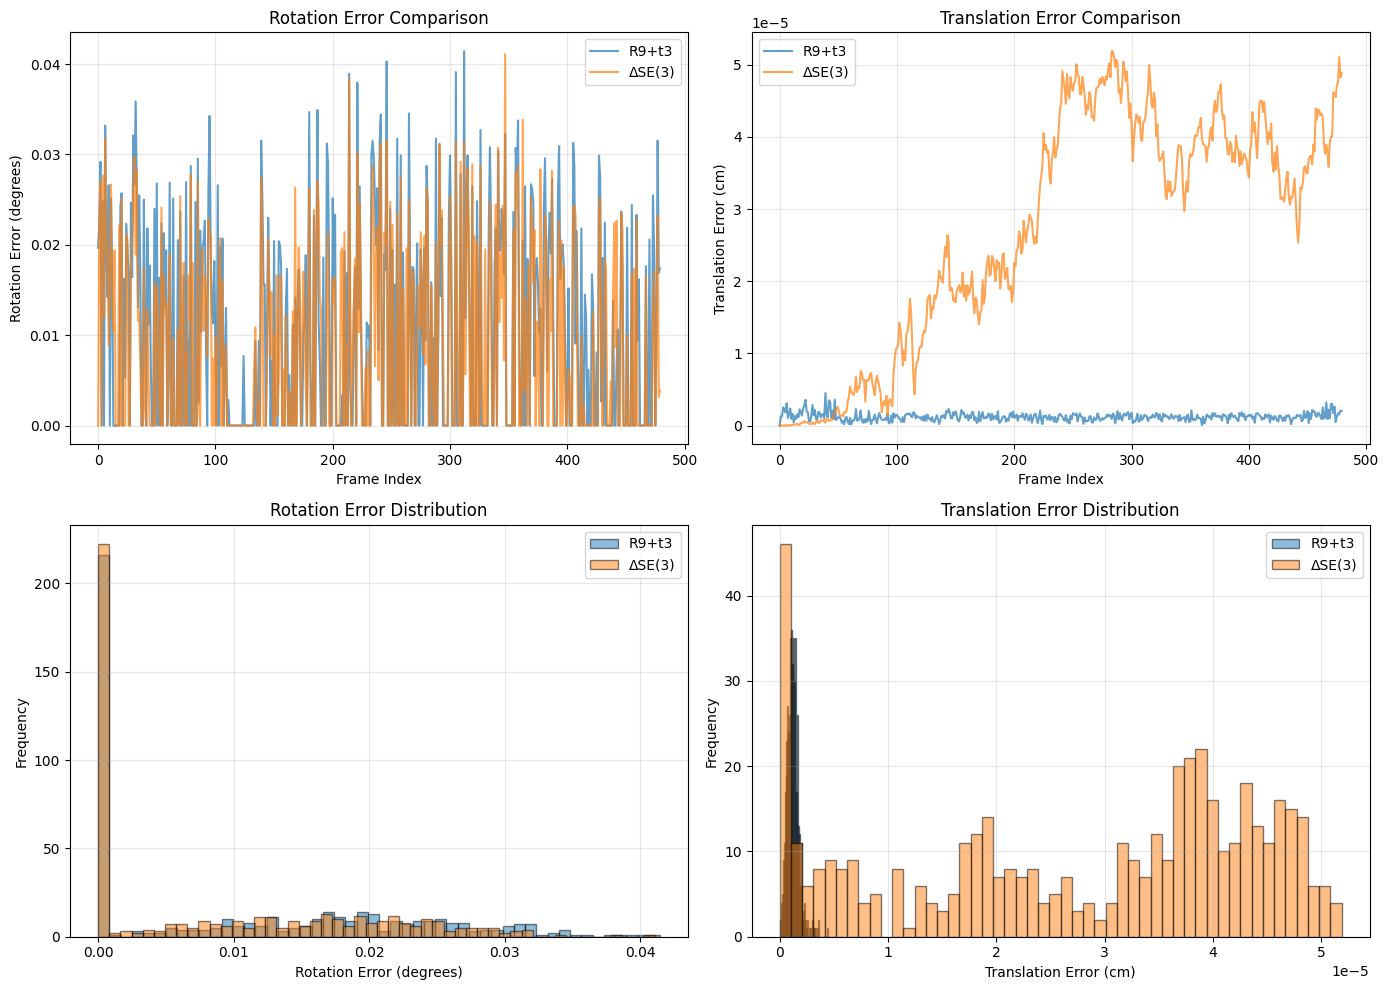

Error comparison plot saved to: artifacts/pouring_overfit_single/50_error_comparison.png


In [52]:
 # Plot error curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rotation error
axes[0, 0].plot(rot_err_abs, label='R9+t3', alpha=0.7, linewidth=1.5)
axes[0, 0].plot(rot_err_delta, label='ΔSE(3)', alpha=0.7, linewidth=1.5)
axes[0, 0].set_xlabel('Frame Index')
axes[0, 0].set_ylabel('Rotation Error (degrees)')
axes[0, 0].set_title('Rotation Error Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Translation error
axes[0, 1].plot(trans_err_abs * 100, label='R9+t3', alpha=0.7, linewidth=1.5)
axes[0, 1].plot(trans_err_delta * 100, label='ΔSE(3)', alpha=0.7, linewidth=1.5)
axes[0, 1].set_xlabel('Frame Index')
axes[0, 1].set_ylabel('Translation Error (cm)')
axes[0, 1].set_title('Translation Error Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Rotation error distribution
axes[1, 0].hist(rot_err_abs, bins=50, alpha=0.5, label='R9+t3', edgecolor='black')
axes[1, 0].hist(rot_err_delta, bins=50, alpha=0.5, label='ΔSE(3)', edgecolor='black')
axes[1, 0].set_xlabel('Rotation Error (degrees)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Rotation Error Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Translation error distribution
axes[1, 1].hist(trans_err_abs * 100, bins=50, alpha=0.5, label='R9+t3', edgecolor='black')
axes[1, 1].hist(trans_err_delta * 100, bins=50, alpha=0.5, label='ΔSE(3)', edgecolor='black')
axes[1, 1].set_xlabel('Translation Error (cm)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Translation Error Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(artifacts_dir / '50_error_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Error comparison plot saved to: {artifacts_dir / '50_error_comparison.png'}")

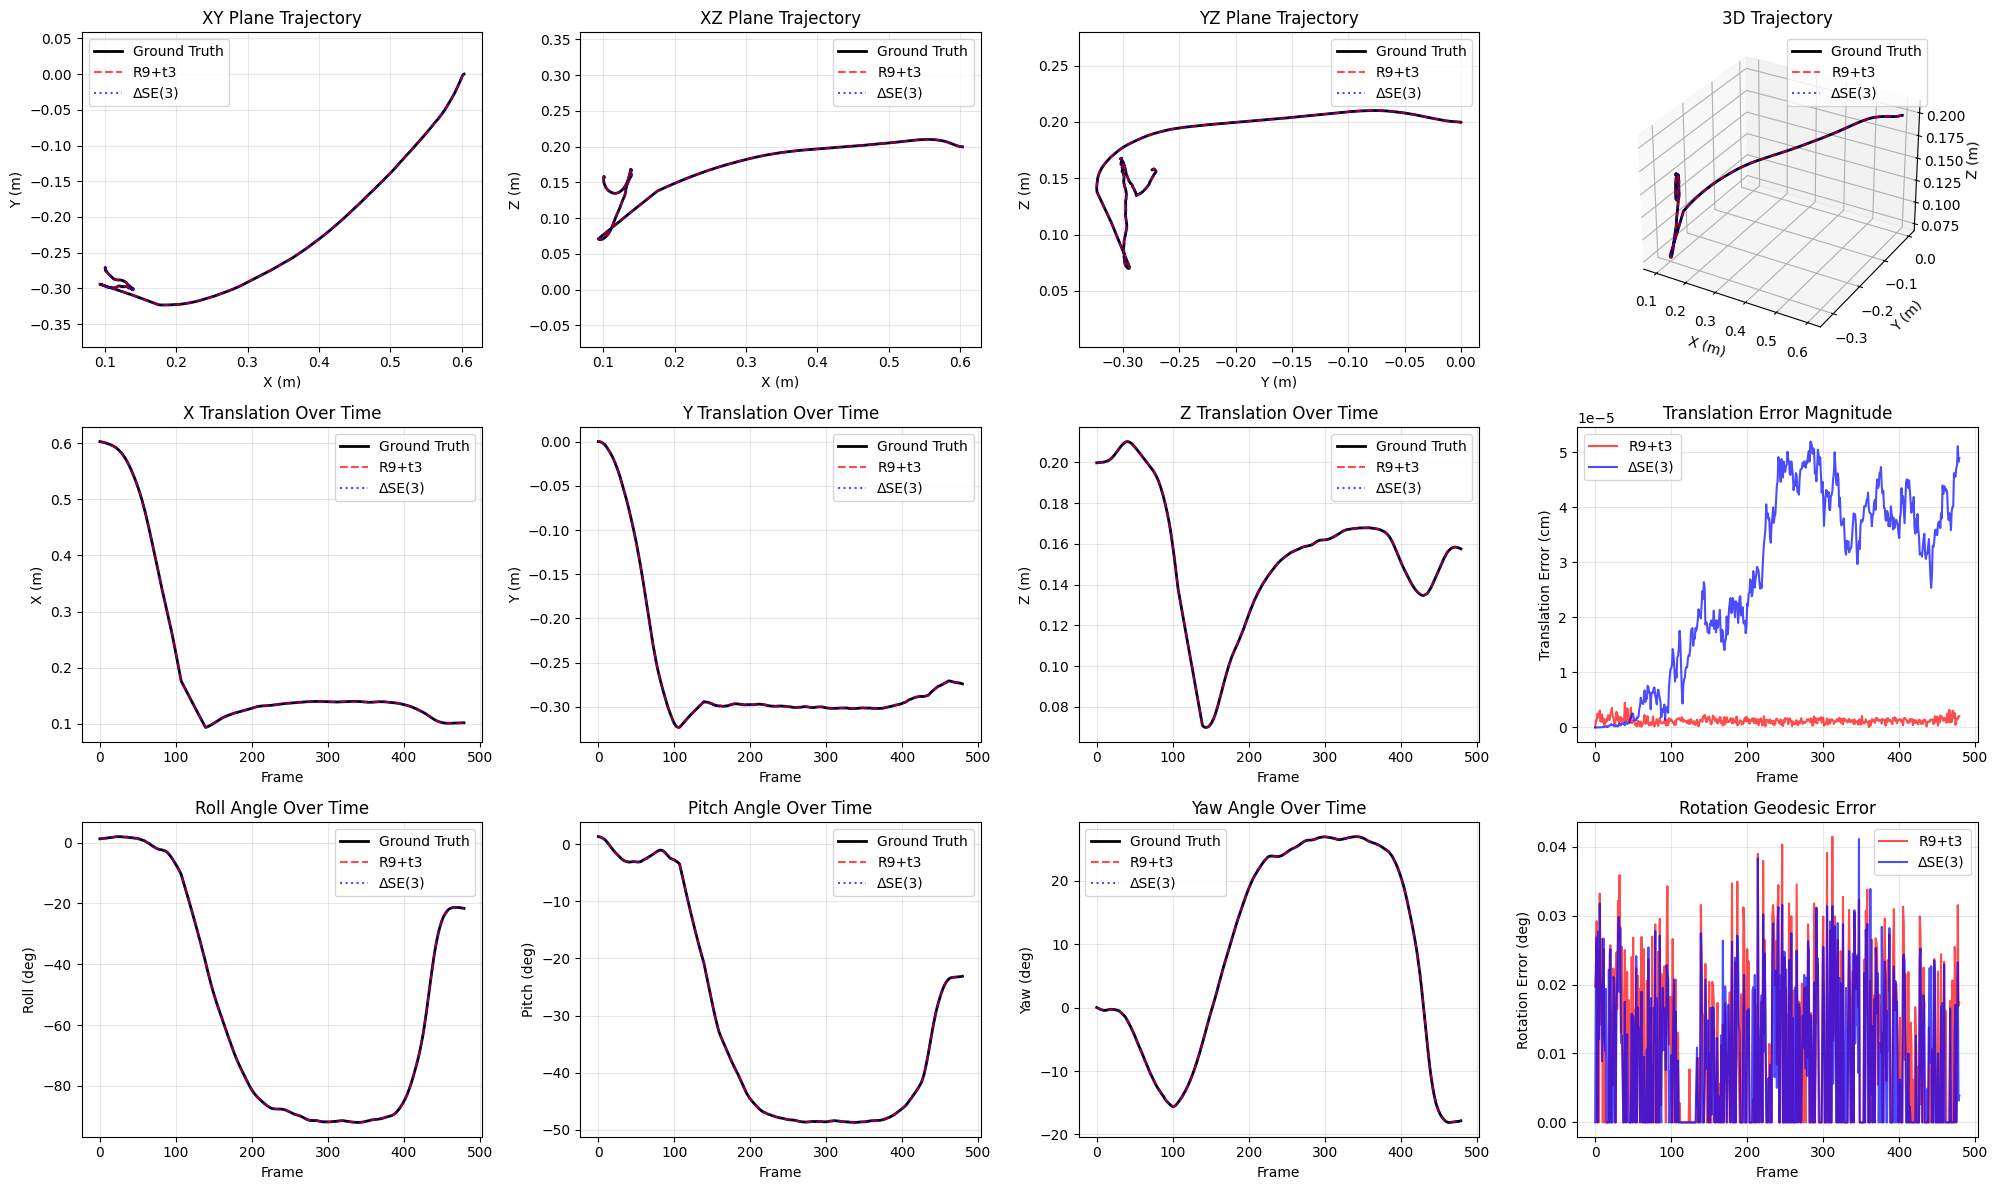

Comprehensive trajectory comparison plot saved to: artifacts/pouring_overfit_single/51_trajectory_comparison_comprehensive.png


In [53]:
# Plot trajectory comparison - comprehensive view
fig = plt.figure(figsize=(20, 12))

# === Translation Trajectories ===
# XY plane
ax1 = fig.add_subplot(3, 4, 1)
ax1.plot(T_seq_raw[:, 0, 3], T_seq_raw[:, 1, 3], 'k-', label='Ground Truth', linewidth=2)
ax1.plot(T_recon_abs[:, 0, 3], T_recon_abs[:, 1, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax1.plot(T_recon_delta_abs[:, 0, 3], T_recon_delta_abs[:, 1, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('XY Plane Trajectory')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# XZ plane
ax2 = fig.add_subplot(3, 4, 2)
ax2.plot(T_seq_raw[:, 0, 3], T_seq_raw[:, 2, 3], 'k-', label='Ground Truth', linewidth=2)
ax2.plot(T_recon_abs[:, 0, 3], T_recon_abs[:, 2, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax2.plot(T_recon_delta_abs[:, 0, 3], T_recon_delta_abs[:, 2, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_title('XZ Plane Trajectory')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# YZ plane
ax3 = fig.add_subplot(3, 4, 3)
ax3.plot(T_seq_raw[:, 1, 3], T_seq_raw[:, 2, 3], 'k-', label='Ground Truth', linewidth=2)
ax3.plot(T_recon_abs[:, 1, 3], T_recon_abs[:, 2, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax3.plot(T_recon_delta_abs[:, 1, 3], T_recon_delta_abs[:, 2, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax3.set_xlabel('Y (m)')
ax3.set_ylabel('Z (m)')
ax3.set_title('YZ Plane Trajectory')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# 3D trajectory
ax4 = fig.add_subplot(3, 4, 4, projection='3d')
ax4.plot(T_seq_raw[:, 0, 3], T_seq_raw[:, 1, 3], T_seq_raw[:, 2, 3], 'k-', label='Ground Truth', linewidth=2)
ax4.plot(T_recon_abs[:, 0, 3], T_recon_abs[:, 1, 3], T_recon_abs[:, 2, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax4.plot(T_recon_delta_abs[:, 0, 3], T_recon_delta_abs[:, 1, 3], T_recon_delta_abs[:, 2, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('X (m)')
ax4.set_ylabel('Y (m)')
ax4.set_zlabel('Z (m)')
ax4.set_title('3D Trajectory')
ax4.legend()

# === Translation Components Over Time ===
frames = np.arange(len(T_seq_raw))

# X component
ax5 = fig.add_subplot(3, 4, 5)
ax5.plot(frames, T_seq_raw[:, 0, 3], 'k-', label='Ground Truth', linewidth=2)
ax5.plot(frames, T_recon_abs[:, 0, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax5.plot(frames, T_recon_delta_abs[:, 0, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax5.set_xlabel('Frame')
ax5.set_ylabel('X (m)')
ax5.set_title('X Translation Over Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Y component
ax6 = fig.add_subplot(3, 4, 6)
ax6.plot(frames, T_seq_raw[:, 1, 3], 'k-', label='Ground Truth', linewidth=2)
ax6.plot(frames, T_recon_abs[:, 1, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax6.plot(frames, T_recon_delta_abs[:, 1, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax6.set_xlabel('Frame')
ax6.set_ylabel('Y (m)')
ax6.set_title('Y Translation Over Time')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Z component
ax7 = fig.add_subplot(3, 4, 7)
ax7.plot(frames, T_seq_raw[:, 2, 3], 'k-', label='Ground Truth', linewidth=2)
ax7.plot(frames, T_recon_abs[:, 2, 3], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax7.plot(frames, T_recon_delta_abs[:, 2, 3], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax7.set_xlabel('Frame')
ax7.set_ylabel('Z (m)')
ax7.set_title('Z Translation Over Time')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Translation error magnitude
ax8 = fig.add_subplot(3, 4, 8)
ax8.plot(frames, trans_err_abs * 100, 'r-', label='R9+t3', linewidth=1.5, alpha=0.7)
ax8.plot(frames, trans_err_delta * 100, 'b-', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax8.set_xlabel('Frame')
ax8.set_ylabel('Translation Error (cm)')
ax8.set_title('Translation Error Magnitude')
ax8.legend()
ax8.grid(True, alpha=0.3)

# === Rotation Analysis ===
# Extract Euler angles (or rotation axis-angle for visualization)
def extract_euler_angles(T_seq):
    """Extract ZYX Euler angles from SE(3) sequence"""
    angles = []
    for T in T_seq:
        R = T[:3, :3]
        # ZYX Euler angles
        sy = np.sqrt(R[0,0]**2 + R[1,0]**2)
        singular = sy < 1e-6
        if not singular:
            x = np.arctan2(R[2,1], R[2,2])
            y = np.arctan2(-R[2,0], sy)
            z = np.arctan2(R[1,0], R[0,0])
        else:
            x = np.arctan2(-R[1,2], R[1,1])
            y = np.arctan2(-R[2,0], sy)
            z = 0
        angles.append([x, y, z])
    return np.degrees(np.array(angles))

euler_gt = extract_euler_angles(T_seq_raw)
euler_abs = extract_euler_angles(T_recon_abs)
euler_delta = extract_euler_angles(T_recon_delta_abs)

# Roll angle
ax9 = fig.add_subplot(3, 4, 9)
ax9.plot(frames, euler_gt[:, 0], 'k-', label='Ground Truth', linewidth=2)
ax9.plot(frames, euler_abs[:, 0], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax9.plot(frames, euler_delta[:, 0], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax9.set_xlabel('Frame')
ax9.set_ylabel('Roll (deg)')
ax9.set_title('Roll Angle Over Time')
ax9.legend()
ax9.grid(True, alpha=0.3)

# Pitch angle
ax10 = fig.add_subplot(3, 4, 10)
ax10.plot(frames, euler_gt[:, 1], 'k-', label='Ground Truth', linewidth=2)
ax10.plot(frames, euler_abs[:, 1], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax10.plot(frames, euler_delta[:, 1], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax10.set_xlabel('Frame')
ax10.set_ylabel('Pitch (deg)')
ax10.set_title('Pitch Angle Over Time')
ax10.legend()
ax10.grid(True, alpha=0.3)

# Yaw angle
ax11 = fig.add_subplot(3, 4, 11)
ax11.plot(frames, euler_gt[:, 2], 'k-', label='Ground Truth', linewidth=2)
ax11.plot(frames, euler_abs[:, 2], 'r--', label='R9+t3', linewidth=1.5, alpha=0.7)
ax11.plot(frames, euler_delta[:, 2], 'b:', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax11.set_xlabel('Frame')
ax11.set_ylabel('Yaw (deg)')
ax11.set_title('Yaw Angle Over Time')
ax11.legend()
ax11.grid(True, alpha=0.3)

# Rotation error
ax12 = fig.add_subplot(3, 4, 12)
ax12.plot(frames, rot_err_abs, 'r-', label='R9+t3', linewidth=1.5, alpha=0.7)
ax12.plot(frames, rot_err_delta, 'b-', label='ΔSE(3)', linewidth=1.5, alpha=0.7)
ax12.set_xlabel('Frame')
ax12.set_ylabel('Rotation Error (deg)')
ax12.set_title('Rotation Geodesic Error')
ax12.legend()
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(artifacts_dir / '51_trajectory_comparison_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Comprehensive trajectory comparison plot saved to: {artifacts_dir / '51_trajectory_comparison_comprehensive.png'}")

## 7. Open3D可视化（可选）

使用提供的visualizer进行3D可视化

In [54]:
# # 注意：此单元格需要在支持GUI的环境中运行
# # 如果在远程服务器或无GUI环境中，请跳过此步骤

# try:
#     from visualizer import TrajectoryVisualizer
    
#     # 检查3D模型路径
#     bottle_path = '../research/Riemannian_Flow/MMLfD-Tutorial_Modified/3dmodels/bottles'
#     mug_path = '../research/Riemannian_Flow/MMLfD-Tutorial_Modified/3dmodels/mugs'
    
#     if os.path.exists(bottle_path) and os.path.exists(mug_path):
#         visualizer = TrajectoryVisualizer(
#             bottle_model_path=bottle_path,
#             mug_model_path=mug_path
#         )
        
#         # 可视化三条轨迹：GT, R9+t3, ΔSE(3)
#         visualizer.visualize(
#             [T_seq_raw, T_recon_abs, T_recon_delta_abs],
#             mode='static',  # 或 'video'
#             skip_size=10
#         )
        
#         visualizer.run()
#     else:
#         print(f"3D模型路径不存在，跳过Open3D可视化")
#         print(f"需要的路径: {bottle_path}, {mug_path}")
        
# except Exception as e:
#     print(f"Open3D可视化失败: {e}")
#     print("这可能是因为运行环境不支持GUI，可以跳过此步骤")

## 8. 总结与分析

In [55]:
print("="*60)
print("预处理管线验证总结")
print("="*60)

print("\n✓ 数据加载: 成功")
print(f"  - 轨迹帧数: {num_frames}")
print(f"  - 数据形状: {T_seq_raw.shape}")

print("\n✓ 方法1 (R9+t3):")
print(f"  - 预处理输出: {Z_abs.shape}")
print(f"  - 重构误差: 旋转 {metrics_abs['rotation']['mean_deg']:.2e}°, 平移 {metrics_abs['translation']['mean_m']*100:.2e} cm")
print(f"  - 结论: {'✓ 管线正确' if metrics_abs['rotation']['mean_deg'] < 1e-3 else '✗ 存在误差'}")

print("\n✓ 方法2 (ΔSE(3)):")
print(f"  - 预处理输出: {Z_delta.shape}")
print(f"  - 重构误差: 旋转 {metrics_delta['rotation']['mean_deg']:.2e}°, 平移 {metrics_delta['translation']['mean_m']*100:.2e} cm")
print(f"  - 结论: {'✓ 管线正确' if metrics_delta['rotation']['mean_deg'] < 1e-3 else '✗ 存在误差'}")

print("\n✓ 输出文件:")
for f in sorted(artifacts_dir.glob('*')):
    print(f"  - {f.name}")

print("\n" + "="*60)
print("预处理管线验证完成！可以进行Flow Matching训练。")
print("="*60)

预处理管线验证总结

✓ 数据加载: 成功
  - 轨迹帧数: 480
  - 数据形状: (480, 4, 4)

✓ 方法1 (R9+t3):
  - 预处理输出: (480, 12)
  - 重构误差: 旋转 1.07e-02°, 平移 1.21e-06 cm
  - 结论: ✗ 存在误差

✓ 方法2 (ΔSE(3)):
  - 预处理输出: (479, 6)
  - 重构误差: 旋转 9.10e-03°, 平移 2.72e-05 cm
  - 结论: ✗ 存在误差

✓ 输出文件:
  - 02_abs_R9_t3_seq.npz
  - 03_delta_se3_seq.npz
  - 04_whiten_abs.json
  - 05_whiten_delta.json
  - 21_recon_abs_T_seq.npz
  - 22_recon_delta_T_seq.npz
  - 41_metrics.json
  - 50_error_comparison.png
  - 51_trajectory_comparison.png
  - 51_trajectory_comparison_comprehensive.png
  - T_0.npy
  - fm_delta_best.pt

预处理管线验证完成！可以进行Flow Matching训练。


---

# Flow Matching 训练部分

以下为Flow Matching模型的训练和推理代码空间

---

# Flow Matching 训练部分（方法2: ΔSE(3)）

基于预处理验证的结果，我们将使用**方法2 (ΔSE(3))**进行Flow Matching训练。

## 9. Flow Matching 模型定义

使用轻量级MLP作为向量场网络，对旋转和平移增量分别归一化。

---

# 🔥 Flow Matching训练部分

使用**方法2 (ΔSE(3))**进行Flow Matching过拟合训练。

## 核心组件
- **数据**：`Z_delta` (479, 6) - 白化后的se(3)增量序列
- **网络**：`EnhancedVectorFieldNet` - CBAM + 多残差Transformer（继承`ModelWrapper`）
- **路径**：`AffinePath(CondOTScheduler())` - OT-CFM插值：x_t = (1-t)x0 + t*x1
- **求解器**：`torchdiffeq.odeint(dopri5)` - 从噪声积分到数据

## 训练流程
1. 定义网络和辅助模块（Mish, ResidualFC, CBAM等）
2. 实现训练函数（使用`path.sample()`计算目标速度场）
3. 超参数扫描（15-20组配置）
4. ODE推理（从标准高斯噪声采样轨迹）
5. 重构SE(3)轨迹并评估误差

---


In [56]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import torchdiffeq  # ODE求解器
import time
from datetime import datetime
import contextlib
import bitsandbytes as bnb

# fmtorch库
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    
print(f"✓ fmtorch版本: {__import__('fmtorch').__version__ if hasattr(__import__('fmtorch'), '__version__') else 'unknown'}")
print(f"✓ torchdiffeq已导入")
print(f"✓ bitsandbytes已导入")

使用设备: cuda
✓ fmtorch版本: unknown
✓ torchdiffeq已导入
✓ bitsandbytes已导入


In [57]:
import math

def fourier_time_embed(t, K=32):
    """Fourier time embedding"""
    # t: (B,1) in [0,1]
    device = t.device
    k = torch.arange(K, device=device, dtype=torch.float32)
    freqs = 2**k * math.pi
    ang = t * freqs
    return torch.cat([torch.sin(ang), torch.cos(ang)], dim=-1)

def sinusoidal_pe(seq_len, hidden_dim):
    """Sinusoidal positional encoding for (B, L, C) format"""
    position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, hidden_dim, 2, dtype=torch.float32) * (-math.log(10000.0) / hidden_dim))
    pe = torch.zeros(1, seq_len, hidden_dim)
    pe[0, :, 0::2] = torch.sin(position * div_term)
    pe[0, :, 1::2] = torch.cos(position * div_term)
    return pe

print("Helper functions for time and position embedding defined.")


Helper functions for time and position embedding defined.


In [58]:
# 定义激活函数和基础模块
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    """全连接残差块（增强版）"""
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.act = Mish()
    
    def forward(self, x):
        residual = x
        # 第一层
        out = self.norm1(x)
        out = self.act(self.fc1(out))
        out = self.dropout(out)
        # 第二层
        out = self.norm2(out)
        out = self.fc2(out)
        out = self.dropout(out)
        # 残差连接
        return self.act(out + residual)

print("激活函数和残差块定义完成！")

激活函数和残差块定义完成！


In [59]:
# CBAM注意力机制（用于序列特征）
class SequenceChannelAttention(nn.Module):
    """序列的通道注意力（类似SE模块）"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: (B, L, C)
        B, L, C = x.shape
        # Global average pooling
        y = self.avg_pool(x.transpose(1, 2)).squeeze(-1)  # (B, C)
        y = self.fc(y).unsqueeze(1)  # (B, 1, C)
        return x * y.expand_as(x)

class SequenceSpatialAttention(nn.Module):
    """序列的空间（时间）注意力"""
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv1d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # x: (B, L, C)
        x_t = x.transpose(1, 2)  # (B, C, L)
        avg_out = torch.mean(x_t, dim=1, keepdim=True)  # (B, 1, L)
        max_out, _ = torch.max(x_t, dim=1, keepdim=True)  # (B, 1, L)
        y = torch.cat([avg_out, max_out], dim=1)  # (B, 2, L)
        y = self.conv(y)  # (B, 1, L)
        y = self.sigmoid(y)  # (B, 1, L)
        return x * y.transpose(1, 2).expand_as(x)

class CBAM1D(nn.Module):
    """CBAM for 1D sequences"""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = SequenceChannelAttention(channels, reduction)
        self.spatial_attention = SequenceSpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

print("CBAM注意力机制定义完成！")

CBAM注意力机制定义完成！


In [60]:
# 定义窗口化的Transformer Encoder层
class WindowedTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.0, window_size=96):
        super().__init__()
        self.window_size = window_size
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        # Feedforward network
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        # Normalization and dropout layers
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = F.gelu

    def forward(self, src):
        # Apply norm_first logic
        x = src
        x = x + self._sa_block(self.norm1(x))
        x = x + self._ff_block(self.norm2(x))
        return x

    def _sa_block(self, x):
        B, L, C = x.shape
        w = self.window_size

        # Pad the sequence to be divisible by window_size
        pad_len = (w - L % w) % w
        if pad_len > 0:
            x = F.pad(x, (0, 0, 0, pad_len))
        
        L_pad = x.shape[1]
        num_windows = L_pad // w

        # Reshape for windowed attention: (B, L, C) -> (B * num_windows, w, C)
        x_windows = x.reshape(B * num_windows, w, C)
        
        # Apply self-attention within each window. MHA uses SDPA internally.
        attn_output, _ = self.self_attn(x_windows, x_windows, x_windows, need_weights=False)
        
        # Reshape back to original batch shape
        attn_output = attn_output.reshape(B, L_pad, C)

        # Truncate the padding
        if pad_len > 0:
            attn_output = attn_output[:, :L, :]

        return self.dropout1(attn_output)

    def _ff_block(self, x):
        x = self.linear2(self.dropout(self.activation(self.linear1(x))))
        return self.dropout2(x)

# 定义增强的向量场网络（继承ModelWrapper）
class EnhancedVectorFieldNet(ModelWrapper):
    def __init__(self, seq_len=479, data_dim=6, hidden_dim=512, num_layers=8, 
                 time_embed_dim=256, dropout=0.0, num_heads=8, reduction=16, window=96,
                 fourier_k=32):
        # 先调用nn.Module的初始化
        nn.Module.__init__(self)
        
        self.seq_len = seq_len
        self.data_dim = data_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.fourier_k = fourier_k
        
        # ============ 时间嵌入 ============
        time_input_dim = fourier_k * 2
        self.time_embed = nn.Sequential(
            nn.Linear(time_input_dim, time_embed_dim), Mish(),
            nn.Linear(time_embed_dim, time_embed_dim), Mish(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )
        
        # ============ 位置编码 ============
        self.register_buffer("pos_emb", sinusoidal_pe(seq_len, hidden_dim), persistent=False)
        
        # ============ 输入投影 ============
        self.input_proj = nn.Sequential(
            nn.Linear(data_dim, hidden_dim), nn.LayerNorm(hidden_dim), Mish()
        )
        
        self.time_proj = nn.Linear(time_embed_dim, hidden_dim)
        
        # ============ CBAM注意力块 ============
        self.cbam_blocks = nn.ModuleList([
            CBAM1D(channels=hidden_dim, reduction=reduction) for _ in range(num_layers // 2)
        ])
        
        # ============ 窗口化Transformer ============
        self.transformer_layers = nn.ModuleList([
            WindowedTransformerEncoderLayer(
                d_model=hidden_dim, nhead=num_heads,
                dim_feedforward=hidden_dim * 2, dropout=dropout,
                window_size=window
            ) for _ in range(num_layers)
        ])
        
        # ============ 额外的残差FC块 ============
        self.fc_blocks = nn.ModuleList([
            ResidualFC(hidden_dim, dropout=dropout) for _ in range(4)
        ])
        
        # ============ 输出投影 ============
        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim // 2),
            Mish(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, data_dim)
        )
        
        print(f"EnhancedVectorFieldNet (Windowed) 初始化:")
        total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  - 可训练参数: {total_params:,}")

    def forward(self, x, t, **kwargs):
        B, L, C = x.shape
        
        # 时间嵌入
        t_feat = fourier_time_embed(t.view(B, 1).float(), K=self.fourier_k)
        t_emb = self.time_embed(t_feat)
        t_cond = self.time_proj(t_emb)
        
        # 输入投影并注入时间和位置
        h = self.input_proj(x) + t_cond.unsqueeze(1)
        h = h + self.pos_emb[:, :L, :]
        
        # CBAM处理
        for cbam in self.cbam_blocks:
            h = cbam(h)
        
        # 窗口化Transformer处理
        for layer in self.transformer_layers:
            h = layer(h)
        
        # 额外的FC残差块
        h_flat = h.reshape(B * L, -1)
        for fc_block in self.fc_blocks:
            h_flat = fc_block(h_flat)
        h = h_flat.reshape(B, L, -1)
        
        # 输出投影
        v = self.output_proj(h)
        return v

print("增强向量场网络（窗口化Transformer）定义完成！")

增强向量场网络（窗口化Transformer）定义完成！


## 10. 数据准备和归一化

对旋转和平移增量分别进行归一化处理。

In [61]:
# 准备训练数据（方法2: ΔSE(3)）
print("准备训练数据...")

# 加载预处理数据
data_npz = np.load(artifacts_dir / '03_delta_se3_seq.npz')
Z_delta_train = data_npz['Z_delta']  # (479, 6) 已白化

# 加载白化统计（用于后续反归一化）
with open(artifacts_dir / '05_whiten_delta.json', 'r') as f:
    whiten_stats = json.load(f)

mu_omega = np.array(whiten_stats['mu_omega'])
sigma_omega = np.array(whiten_stats['sigma_omega'])
mu_v = np.array(whiten_stats['mu_v'])
sigma_v = np.array(whiten_stats['sigma_v'])

print(f"训练数据形状: {Z_delta_train.shape}")
print(f"数据统计: mean={Z_delta_train.mean():.6f}, std={Z_delta_train.std():.6f}")

# 转换为PyTorch张量
Z_delta_tensor = torch.from_numpy(Z_delta_train).float().unsqueeze(0)  # (1, 479, 6)
print(f"张量形状: {Z_delta_tensor.shape}")

准备训练数据...
训练数据形状: (479, 6)
数据统计: mean=0.000000, std=0.999994
张量形状: torch.Size([1, 479, 6])


## 11. 超参数Sweep配置

设计15-20个sweep配置，搜索：
- 网络大小（hidden_dim, num_layers）
- 学习率调度策略（cosine annealing, plateau, constant）
- 初始学习率

In [62]:
# 定义Sweep配置（使用增强网络）
sweep_configs = []

# 基础配置
base_config = {
    'seq_len': 479,
    'data_dim': 6,
    'n_epochs': 5000,
    'micro_batch_size': 8, 
    'acc_steps': 64, # Effective batch size = 8 * 64 = 512
    'time_embed_dim': 256,
    'dropout': 0.0,
    'weight_decay': 1e-5,
    'grad_clip': 1.0,
    'num_heads': 2,
    'reduction': 16,
    'window': 96,
    'fourier_k': 32
}

# 最终优化配置
sweep_configs.append({
    **base_config,
    'hidden_dim': 256,
    'num_layers': 4,
    'lr': 1e-3,
    'scheduler': 'cosine',
    'name': f'h256_l4_cosine_upgraded'
})

sweep_configs.append({
    **base_config,
    'hidden_dim': 256,
    'num_layers': 4,
    'lr': 1e-3,
    'scheduler': 'plateau',
    'name': f'h256_l4_plateau_upgraded'
})

print(f"总共 {len(sweep_configs)} 个sweep配置")
print(f"\n当前配置:")
for i, cfg in enumerate(sweep_configs):
    print(f"  {i+1}. {cfg['name']}:")
    print(f"     - micro_bs={cfg['micro_batch_size']}, acc_steps={cfg['acc_steps']}, "
          f"eff_bs={cfg['micro_batch_size'] * cfg['acc_steps']}")
    print(f"     - hidden={cfg['hidden_dim']}, layers={cfg['num_layers']}, "
          f"heads={cfg['num_heads']}, window={cfg['window']}")
    print(f"     - scheduler={cfg['scheduler']}, lr={cfg['lr']}")

总共 2 个sweep配置

当前配置:
  1. h256_l4_cosine_upgraded:
     - micro_bs=8, acc_steps=64, eff_bs=512
     - hidden=256, layers=4, heads=2, window=96
     - scheduler=cosine, lr=0.001
  2. h256_l4_plateau_upgraded:
     - micro_bs=8, acc_steps=64, eff_bs=512
     - hidden=256, layers=4, heads=2, window=96
     - scheduler=plateau, lr=0.001


### 💡 关于Batch Size

**为什么在过拟合单样本时使用大batch size (4096)?**

虽然我们只有一个数据样本，但Flow Matching的训练过程包含两个随机性来源：
1. **随机时间采样**：每次迭代随机采样 t ~ U(0,1)
2. **随机噪声采样**：每次迭代随机采样 x₀ ~ N(0,I)

对于固定的数据点 x₁（我们的单个轨迹），每个不同的 (t, x₀) 组合会产生不同的：
- **插值路径**：x_t = (1-t)·x₀ + t·x₁  
- **目标速度场**：dx_t = x₁ - x₀

**大batch size的好处**：
- ✅ 每次迭代覆盖更多的 (t, x₀) 组合
- ✅ 梯度估计更准确、更稳定
- ✅ 收敛更快、训练更鲁棒
- ✅ 更好地学习整个时间区间 [0,1] 和噪声空间的向量场

这类似于标准深度学习中增加batch size以稳定梯度，只是这里的"样本"是对同一数据点的不同随机插值路径。

---


## 12. Flow Matching 训练函数

使用OT-CFM (Optimal Transport Conditional Flow Matching)训练向量场。

In [63]:
def train_flow_matching(model, data, config, device):
    model = model.to(device)
    data = data.to(device)
    
    path = AffinePath(scheduler=CondOTScheduler())
    
    # 使用bitsandbytes的8-bit AdamW优化器
    optimizer = bnb.optim.AdamW8bit(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    if config['scheduler'] == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=config['n_epochs'], eta_min=config['lr'] * 0.01)
    elif config['scheduler'] == 'plateau':
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True)
    else:
        scheduler = None

    use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
    print(f"使用 bfloat16: {use_bf16}")
    
    model.train()
    loss_history = []
    best_loss = float('inf')
    start_time = time.time()
    
    micro_bs = config['micro_batch_size']
    acc_steps = config['acc_steps']

    for epoch in range(config['n_epochs']):
        optimizer.zero_grad(set_to_none=True)
        
        # 梯度累积
        accumulated_loss = 0.0
        for step in range(acc_steps):
            x1 = data.expand(micro_bs, -1, -1)
            x0 = torch.randn_like(x1)
            t = torch.rand(micro_bs, device=device)
            s = path.sample(t=t, x_0=x0, x_1=x1)
            
            # 使用AMP (bfloat16 if available)
            ctx = torch.cuda.amp.autocast(dtype=torch.bfloat16) if use_bf16 else contextlib.nullcontext()
            with ctx:
                pred_v = model(s.x_t, s.t)
                loss = F.mse_loss(pred_v, s.dx_t) / acc_steps
            
            # 反向传播
            loss.backward()
            accumulated_loss += loss.item()

        # 梯度裁剪和优化器步骤
        torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
        optimizer.step()
        
        loss_val = accumulated_loss * acc_steps # 恢复为真实损失
        
        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(loss_val)
            else:
                scheduler.step()
            
        loss_history.append(loss_val)
        
        if loss_val < best_loss:
            best_loss = loss_val
            
        if (epoch + 1) % 500 == 0:
            elapsed = time.time() - start_time
            lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch+1}/{config['n_epochs']} | Loss: {loss_val:.6f} | Best: {best_loss:.6f} | LR: {lr:.6f} | Time: {elapsed:.1f}s")
    
    return best_loss, loss_history

print("训练函数已更新（梯度累积, bfloat16, 8-bit AdamW）！")

训练函数已更新（梯度累积, bfloat16, 8-bit AdamW）！


## 13. 运行Sweep实验

对所有配置进行训练，只保存最佳模型权重。

In [64]:
# 运行sweep实验
sweep_results = []
best_overall_loss = float('inf')
best_overall_config = None
best_overall_model = None

print("="*80)
print(f"开始Sweep实验: {len(sweep_configs)} 个配置")
print("="*80)

for sweep_idx, config in enumerate(sweep_configs):
    print(f"\n[Sweep {sweep_idx+1}/{len(sweep_configs)}] 配置: {config['name']}")
    print(f"  hidden_dim={config['hidden_dim']}, num_layers={config['num_layers']}, "
          f"lr={config['lr']}, scheduler={config['scheduler']}")
    
    # 创建增强模型
    model = EnhancedVectorFieldNet(
        seq_len=config['seq_len'],
        data_dim=config['data_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        time_embed_dim=config['time_embed_dim'],
        dropout=config['dropout'],
        num_heads=config['num_heads'],
        reduction=config['reduction'],
        window=config['window'],
        fourier_k=config['fourier_k']
    )
    
    # 训练
    best_loss, loss_history = train_flow_matching(
        model, Z_delta_tensor, config, device
    )
    
    # 记录结果
    result = {
        'name': config['name'],
        'config': config,
        'best_loss': best_loss,
        'final_loss': loss_history[-1],
        'loss_history': loss_history
    }
    sweep_results.append(result)
    
    print(f"  ✓ 完成 | 最佳损失: {best_loss:.6f} | 最终损失: {loss_history[-1]:.6f}")
    
    # 更新全局最佳
    if best_loss < best_overall_loss:
        best_overall_loss = best_loss
        best_overall_config = config
        best_overall_model = model
        
        # 保存最佳模型
        save_path = artifacts_dir / 'fm_delta_best.pt'
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config,
            'best_loss': best_loss,
            'whiten_stats': whiten_stats,
            'T_0': np.load(artifacts_dir / 'T_0.npy')
        }, save_path)
        print(f"  💾 保存全局最佳模型: {save_path}")

print("\n" + "="*80)
print("Sweep实验完成！")
print("="*80)
print(f"\n最佳配置: {best_overall_config['name']}")
print(f"最佳损失: {best_overall_loss:.6f}")

开始Sweep实验: 2 个配置

[Sweep 1/2] 配置: h256_l4_cosine_upgraded
  hidden_dim=256, num_layers=4, lr=0.001, scheduler=cosine
EnhancedVectorFieldNet (Windowed) 初始化:
  - 可训练参数: 2,905,762
使用 bfloat16: True


/tmp/ipykernel_1105632/1301519539.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx = torch.cuda.amp.autocast(dtype=torch.bfloat16) if use_bf16 else contextlib.nullcontext()


  Epoch 500/5000 | Loss: 3.576500 | Best: 3.115848 | LR: 0.000976 | Time: 254.2s
  Epoch 1000/5000 | Loss: 0.894965 | Best: 0.833324 | LR: 0.000905 | Time: 508.8s
  Epoch 1500/5000 | Loss: 0.630975 | Best: 0.362006 | LR: 0.000796 | Time: 762.6s
  Epoch 2000/5000 | Loss: 0.551922 | Best: 0.286875 | LR: 0.000658 | Time: 1017.1s
  Epoch 2500/5000 | Loss: 0.395826 | Best: 0.214197 | LR: 0.000505 | Time: 1271.0s
  Epoch 3000/5000 | Loss: 0.252517 | Best: 0.163881 | LR: 0.000352 | Time: 1525.9s
  Epoch 3500/5000 | Loss: 0.132241 | Best: 0.132241 | LR: 0.000214 | Time: 1780.0s
  Epoch 4000/5000 | Loss: 0.290247 | Best: 0.103891 | LR: 0.000105 | Time: 2034.7s
  Epoch 4500/5000 | Loss: 0.347602 | Best: 0.079240 | LR: 0.000034 | Time: 2289.3s
  Epoch 5000/5000 | Loss: 0.376787 | Best: 0.079240 | LR: 0.000010 | Time: 2543.3s
  ✓ 完成 | 最佳损失: 0.079240 | 最终损失: 0.376787
  💾 保存全局最佳模型: artifacts/pouring_overfit_single/fm_delta_best.pt

[Sweep 2/2] 配置: h256_l4_plateau_upgraded
  hidden_dim=256, num_layer

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 14. Sweep结果分析与可视化

In [65]:
# 整理sweep结果
results_summary = []
for result in sweep_results:
    results_summary.append({
        'name': result['name'],
        'hidden_dim': result['config']['hidden_dim'],
        'num_layers': result['config']['num_layers'],
        'lr': result['config']['lr'],
        'scheduler': result['config']['scheduler'],
        'best_loss': result['best_loss'],
        'final_loss': result['final_loss']
    })

# 按最佳损失排序
results_summary.sort(key=lambda x: x['best_loss'])

print("="*80)
print("Sweep结果排行榜 (Top 10)")
print("="*80)
print(f"{'排名':<5} {'配置名称':<25} {'隐藏层':<8} {'层数':<6} {'学习率':<10} {'调度器':<10} {'最佳损失':<12}")
print("-"*80)
for i, r in enumerate(results_summary[:10]):
    print(f"{i+1:<5} {r['name']:<25} {r['hidden_dim']:<8} {r['num_layers']:<6} "
          f"{r['lr']:<10.6f} {r['scheduler']:<10} {r['best_loss']:<12.6f}")

# 保存结果
with open(artifacts_dir / 'sweep_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"\n结果已保存到: {artifacts_dir / 'sweep_results.json'}")

Sweep结果排行榜 (Top 10)
排名    配置名称                      隐藏层      层数     学习率        调度器        最佳损失        
--------------------------------------------------------------------------------
1     h256_l4_cosine_upgraded   256      4      0.001000   cosine     0.079240    

结果已保存到: artifacts/pouring_overfit_single/sweep_results.json


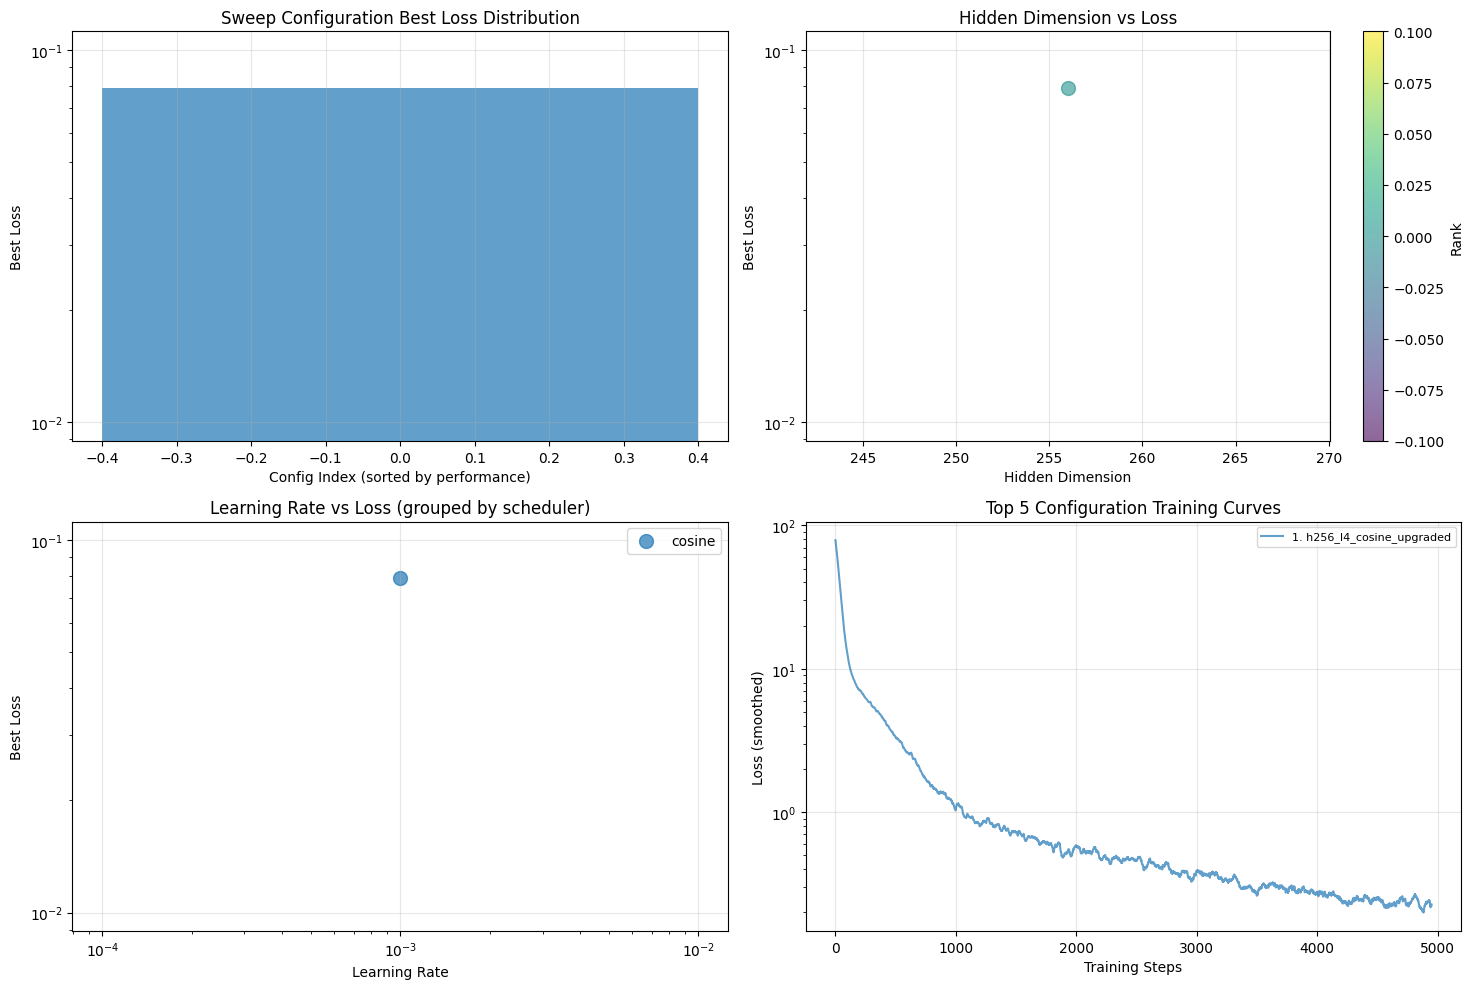

Sweep results visualization saved to: artifacts/pouring_overfit_single/60_sweep_results.png


In [67]:
# Visualize sweep results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Best loss distribution
ax = axes[0, 0]
best_losses = [r['best_loss'] for r in results_summary]
ax.bar(range(len(best_losses)), best_losses, alpha=0.7)
ax.set_xlabel('Config Index (sorted by performance)')
ax.set_ylabel('Best Loss')
ax.set_title('Sweep Configuration Best Loss Distribution')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 2. Hidden dimension vs loss
ax = axes[0, 1]
hidden_dims = [r['hidden_dim'] for r in results_summary]
best_losses = [r['best_loss'] for r in results_summary]
scatter = ax.scatter(hidden_dims, best_losses, c=range(len(hidden_dims)), 
                     cmap='viridis', alpha=0.6, s=100)
ax.set_xlabel('Hidden Dimension')
ax.set_ylabel('Best Loss')
ax.set_title('Hidden Dimension vs Loss')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.colorbar(scatter, ax=ax, label='Rank')

# 3. Learning rate vs loss
ax = axes[1, 0]
lrs = [r['lr'] for r in results_summary]
schedulers = [r['scheduler'] for r in results_summary]
for sched in set(schedulers):
    mask = [s == sched for s in schedulers]
    lr_subset = [lrs[i] for i in range(len(lrs)) if mask[i]]
    loss_subset = [best_losses[i] for i in range(len(best_losses)) if mask[i]]
    ax.scatter(lr_subset, loss_subset, label=sched, alpha=0.7, s=100)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Best Loss')
ax.set_title('Learning Rate vs Loss (grouped by scheduler)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Training curves for top 5
ax = axes[1, 1]
for i in range(min(5, len(sweep_results))):
    result = sweep_results[i]
    # Find corresponding result (sorted by best loss)
    name = results_summary[i]['name']
    for r in sweep_results:
        if r['name'] == name:
            loss_history = r['loss_history']
            # Smooth curve (moving average)
            window = 50
            if len(loss_history) > window:
                smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
            else:
                smoothed = loss_history
            ax.plot(smoothed, label=f"{i+1}. {name}", alpha=0.7, linewidth=1.5)
            break
ax.set_xlabel('Training Steps')
ax.set_ylabel('Loss (smoothed)')
ax.set_title('Top 5 Configuration Training Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(artifacts_dir / '60_sweep_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sweep results visualization saved to: {artifacts_dir / '60_sweep_results.png'}")

## 15. Flow Matching 推理和轨迹重构

使用最佳模型进行推理，重构SE(3)轨迹。

In [69]:
# 加载最佳模型
print("加载最佳模型...")
checkpoint = torch.load(artifacts_dir / 'fm_delta_best.pt', map_location=device, weights_only=False)

best_model = EnhancedVectorFieldNet(
    seq_len=checkpoint['config']['seq_len'],
    data_dim=checkpoint['config']['data_dim'],
    hidden_dim=checkpoint['config']['hidden_dim'],
    num_layers=checkpoint['config']['num_layers'],
    time_embed_dim=checkpoint['config']['time_embed_dim'],
    dropout=checkpoint['config']['dropout'],
    num_heads=checkpoint['config']['num_heads'],
    reduction=checkpoint['config']['reduction']
)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model = best_model.to(device)
best_model.eval()

print(f"✓ 已加载模型: {checkpoint['config']['name']}")
print(f"  最佳损失: {checkpoint['best_loss']:.6f}")

加载最佳模型...
EnhancedVectorFieldNet (Windowed) 初始化:
  - 可训练参数: 2,905,762
✓ 已加载模型: h256_l4_cosine_upgraded
  最佳损失: 0.079240


In [70]:
# Flow Matching推理（使用torchdiffeq）
print("\n开始Flow Matching推理...")

best_model.eval()

with torch.no_grad():
    # 初始噪声
    x0 = torch.randn(1, 479, 6, device=device)
    
    # ============ 定义ODE函数（用于torchdiffeq） ============
    def ode_func(t, x_flat):
        """
        ODE右侧函数: dx/dt = v_θ(x, t)
        
        Args:
            t: 标量时间
            x_flat: 展平的状态向量 (B*L*C,)
        Returns:
            v_flat: 展平的速度向量 (B*L*C,)
        """
        # 重塑为序列
        x = x_flat.view(1, 479, 6)
        
        # 时间标量转为张量
        t_tensor = torch.tensor([float(t)], device=device)
        
        # 预测向量场
        v = best_model(x, t_tensor)
        
        # 展平返回
        return v.view(-1)
    
    # ============ 使用torchdiffeq求解ODE ============
    print("  使用torchdiffeq求解ODE (t=0 -> t=1)...")
    
    t_span = torch.tensor([0.0, 1.0], device=device)
    
    result = torchdiffeq.odeint(
        ode_func,
        x0.view(-1),  # 展平初始状态
        t_span,
        method='dopri5',  # Dormand-Prince 5(4) 方法
        rtol=1e-5,
        atol=1e-5,
        options={'max_num_steps': 1000}
    )
    
    # 提取最终结果
    Z_delta_sampled = result[-1].view(1, 479, 6).cpu().numpy()[0]  # (479, 6)
    
    print(f"  ✓ ODE求解完成")
    print(f"  采样结果形状: {Z_delta_sampled.shape}")
    print(f"  使用方法: torchdiffeq.odeint (dopri5)")

# 反白化
print("\n反白化...")
omega_sampled = Z_delta_sampled[:, :3] * sigma_omega + mu_omega
v_sampled = Z_delta_sampled[:, 3:] * sigma_v + mu_v
xi_sampled = np.concatenate([omega_sampled, v_sampled], axis=1)

print(f"  旋转增量范数范围: [{np.linalg.norm(omega_sampled, axis=1).min():.6f}, "
      f"{np.linalg.norm(omega_sampled, axis=1).max():.6f}] rad")
print(f"  平移增量范数范围: [{np.linalg.norm(v_sampled, axis=1).min():.6f}, "
      f"{np.linalg.norm(v_sampled, axis=1).max():.6f}] m")


开始Flow Matching推理...
  使用torchdiffeq求解ODE (t=0 -> t=1)...
  ✓ ODE求解完成
  采样结果形状: (479, 6)
  使用方法: torchdiffeq.odeint (dopri5)

反白化...
  旋转增量范数范围: [0.000121, 0.030000] rad
  平移增量范数范围: [0.000042, 0.008589] m


In [71]:
# 重构SE(3)轨迹
print("\n重构SE(3)轨迹...")

# 加载T_0（首帧对齐矩阵）
T_0 = checkpoint['T_0']

# 从增量重建轨迹
T_fm_delta = np.zeros((num_frames, 4, 4))
T_fm_delta[0] = np.eye(4)  # 对齐空间的起点

for k in range(1, num_frames):
    # 指数映射
    delta_T_hat = se3_exp(xi_sampled[k-1])
    T_fm_delta[k] = T_fm_delta[k-1] @ delta_T_hat
    
    # SO(3)投影
    T_fm_delta[k, :3, :3] = project_to_SO3(T_fm_delta[k, :3, :3])

# 恢复到原始坐标系
T_fm_abs = np.zeros_like(T_fm_delta)
for k in range(num_frames):
    T_fm_abs[k] = T_0 @ T_fm_delta[k]

print(f"  ✓ 轨迹重构完成")
print(f"  输出形状: {T_fm_abs.shape}")

# 保存FM生成的轨迹
np.savez(artifacts_dir / '23_fm_delta_T_seq.npz', T_hat=T_fm_abs)
print(f"  💾 已保存到: {artifacts_dir / '23_fm_delta_T_seq.npz'}")


重构SE(3)轨迹...
  ✓ 轨迹重构完成
  输出形状: (480, 4, 4)
  💾 已保存到: artifacts/pouring_overfit_single/23_fm_delta_T_seq.npz


## 16. Flow Matching 生成结果评估

对比Ground Truth vs 预处理重构 vs FM生成。

In [72]:
# 评估FM生成结果
print("评估Flow Matching生成结果...")

metrics_fm, rot_err_fm, trans_err_fm = evaluate_reconstruction(
    T_seq_raw, T_fm_abs, 'FM-ΔSE(3)')

print("="*60)
print("Flow Matching生成结果评估")
print("="*60)
print(f"  旋转误差:")
print(f"    平均: {metrics_fm['rotation']['mean_deg']:.6f}°")
print(f"    最大: {metrics_fm['rotation']['max_deg']:.6f}°")
print(f"    P95:  {metrics_fm['rotation']['p95_deg']:.6f}°")
print(f"  平移误差:")
print(f"    平均: {metrics_fm['translation']['mean_m']*100:.6f} cm")
print(f"    最大: {metrics_fm['translation']['max_m']*100:.6f} cm")
print(f"    P95:  {metrics_fm['translation']['p95_m']*100:.6f} cm")
print(f"  端点误差:")
print(f"    旋转: {metrics_fm['endpoint']['rot_rad']:.6f} rad ({np.degrees(metrics_fm['endpoint']['rot_rad']):.6f}°)")
print(f"    平移: {metrics_fm['endpoint']['trans_m']*100:.6f} cm")

# 保存评估结果
all_metrics['FM_delta_se3'] = metrics_fm
with open(artifacts_dir / '41_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

评估Flow Matching生成结果...
Flow Matching生成结果评估
  旋转误差:
    平均: 0.141381°
    最大: 0.271342°
    P95:  0.262420°
  平移误差:
    平均: 0.107985 cm
    最大: 0.137903 cm
    P95:  0.133456 cm
  端点误差:
    旋转: 0.004728 rad (0.270904°)
    平移: 0.123385 cm


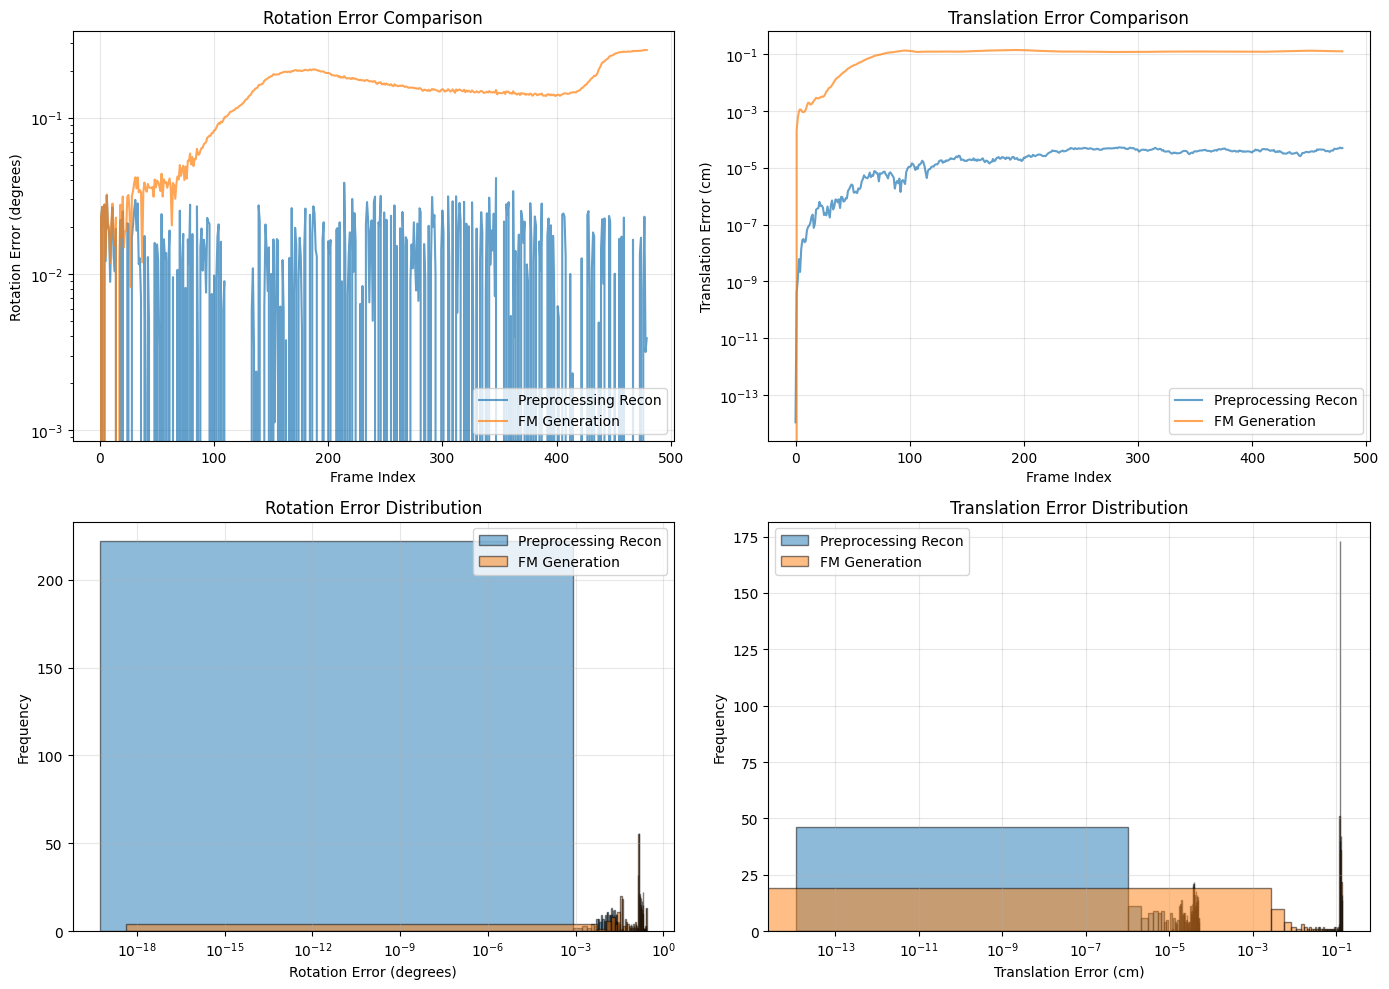


Comparison plot saved to: artifacts/pouring_overfit_single/61_fm_vs_recon_comparison.png


In [74]:
# Visualization comparison: Preprocessing reconstruction vs FM generation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rotation error comparison
axes[0, 0].plot(rot_err_delta, label='Preprocessing Recon', alpha=0.7, linewidth=1.5)
axes[0, 0].plot(rot_err_fm, label='FM Generation', alpha=0.7, linewidth=1.5)
axes[0, 0].set_xlabel('Frame Index')
axes[0, 0].set_ylabel('Rotation Error (degrees)')
axes[0, 0].set_title('Rotation Error Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Translation error comparison
axes[0, 1].plot(trans_err_delta * 100, label='Preprocessing Recon', alpha=0.7, linewidth=1.5)
axes[0, 1].plot(trans_err_fm * 100, label='FM Generation', alpha=0.7, linewidth=1.5)
axes[0, 1].set_xlabel('Frame Index')
axes[0, 1].set_ylabel('Translation Error (cm)')
axes[0, 1].set_title('Translation Error Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_yscale('log')

# Error distribution
axes[1, 0].hist(rot_err_delta, bins=50, alpha=0.5, label='Preprocessing Recon', edgecolor='black')
axes[1, 0].hist(rot_err_fm, bins=50, alpha=0.5, label='FM Generation', edgecolor='black')
axes[1, 0].set_xlabel('Rotation Error (degrees)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Rotation Error Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

axes[1, 1].hist(trans_err_delta * 100, bins=50, alpha=0.5, label='Preprocessing Recon', edgecolor='black')
axes[1, 1].hist(trans_err_fm * 100, bins=50, alpha=0.5, label='FM Generation', edgecolor='black')
axes[1, 1].set_xlabel('Translation Error (cm)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Translation Error Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.savefig(artifacts_dir / '61_fm_vs_recon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparison plot saved to: {artifacts_dir / '61_fm_vs_recon_comparison.png'}")

In [86]:
## 17. 3D 可视化对比 (Open3D)

# 使用Open3D来可视化**Ground Truth**和**Flow Matching生成**的3D轨迹。
from copy import deepcopy
import open3d as o3d
import traceback

# 定义一个变量来检查导入是否成功
VIS_UTILS_AVAILABLE = False
try:
    # 动态添加路径以便在Jupyter中找到vis_utils
    # ../ -> Dian_Experiment; ../../ -> Riemannian_Flow; ../../../ -> research
    module_path = os.path.abspath(os.path.join(os.getcwd(), '../MMLfD-Tutorial_Modified'))
    if module_path not in sys.path:
        sys.path.append(module_path)
        
    from vis_utils.open3d_utils import get_mesh_bottle, get_mesh_mug
    VIS_UTILS_AVAILABLE = True
except ImportError:
    print("警告: 无法导入 'vis_utils'。将跳过直接可视化，并保存数据以供离线脚本使用。")
    print(f"尝试从以下路径添加模块: {module_path}")
    traceback.print_exc(limit=1)


def visualize_or_save_trajectories(trajectories, labels, colors, skip_size=1, save_path=None):
    """
    如果可视化库可用，则进行3D可视化；否则，将轨迹数据保存到文件。
    """
    if not VIS_UTILS_AVAILABLE:
        print("\n可视化库不可用，正在保存轨迹数据...")
        try:
            np.savez(
                save_path,
                T_seq_raw=trajectories[0],
                T_fm_abs=trajectories[1],
                bottle_idx=data.get('bottle_idx'),
                mug_idx=data.get('mug_idx'),
                offset=data.get('offset')
            )
            print(f"✓ 数据已成功保存到: {save_path}")
            print("您现在可以运行 'visualize_saved_trajectories.py' 脚本来进行可视化。")
        except Exception as e:
            print(f"✗ 保存文件时出错: {e}")
        return

    print("初始化3D可视化...")
    
    # --- 1. 加载3D模型 ---
    try:
        bottle_idx = data['bottle_idx']
        mug_idx = data['mug_idx']
        model_root_dir = '../MMLfD-Tutorial_Modified'
        mesh_bottle = get_mesh_bottle(root=os.path.join(model_root_dir, '3dmodels/bottles'), bottle_idx=bottle_idx)
        mesh_mug = get_mesh_mug(root=os.path.join(model_root_dir, '3dmodels/mugs'), mug_idx=mug_idx)
        if mesh_bottle is None or mesh_mug is None: raise FileNotFoundError("get_mesh_bottle/mug returned None.")
        mesh_bottle.compute_vertex_normals()
        mesh_mug.compute_vertex_normals()
    except Exception as e:
        print(f"错误: 加载3D模型失败: {e}")
        return
    
    # --- 2. 创建场景元素 ---
    geometries = []
    mesh_table = o3d.geometry.TriangleMesh.create_box(width=1.5, height=1.5, depth=0.02)
    mesh_table.translate([-0.75, -0.75, -0.02])
    mesh_table.paint_uniform_color([0.8, 0.6, 0.4])
    mesh_table.compute_vertex_normals()
    geometries.append(mesh_table)
    
    mesh_mug.paint_uniform_color([0.5, 0.5, 0.5])
    geometries.append(mesh_mug)

    # --- 3. 渲染轨迹 ---
    print("渲染轨迹...")
    for i, (traj, label, color) in enumerate(zip(trajectories, labels, colors)):
        print(f"  - {label} (颜色: {color}, {len(range(0, len(traj), skip_size))} 个实例)")
        for t_idx in range(0, len(traj), skip_size):
            T = traj[t_idx]
            bottle_instance = deepcopy(mesh_bottle)
            bottle_instance.transform(T)
            bottle_instance.paint_uniform_color(color)
            geometries.append(bottle_instance)
            
    # --- 4. 可视化 ---
    print("启动Open3D窗口...")
    o3d.visualization.draw_geometries(geometries, window_name=f"轨迹对比: {', '.join(labels)}", width=1280, height=720)
    print("可视化窗口已关闭。")

# --- 调用函数 ---
color_gt = [0.1, 0.8, 0.1]  # 绿色
color_fm = [0.9, 0.2, 0.2]  # 红色

visualize_or_save_trajectories(
    trajectories=[T_seq_raw, T_fm_abs],
    labels=["Ground Truth", "FM Generated"],
    colors=[color_gt, color_fm],
    skip_size=20,  # 生成所有帧
    save_path=artifacts_dir / 'trajectories_for_visualizer.npz'
)


初始化3D可视化...
[Open3D INFO] Skipping non-triangle primitive geometry of type: 2
渲染轨迹...
  - Ground Truth (颜色: [0.1, 0.8, 0.1], 24 个实例)
  - FM Generated (颜色: [0.9, 0.2, 0.2], 24 个实例)
启动Open3D窗口...
可视化窗口已关闭。


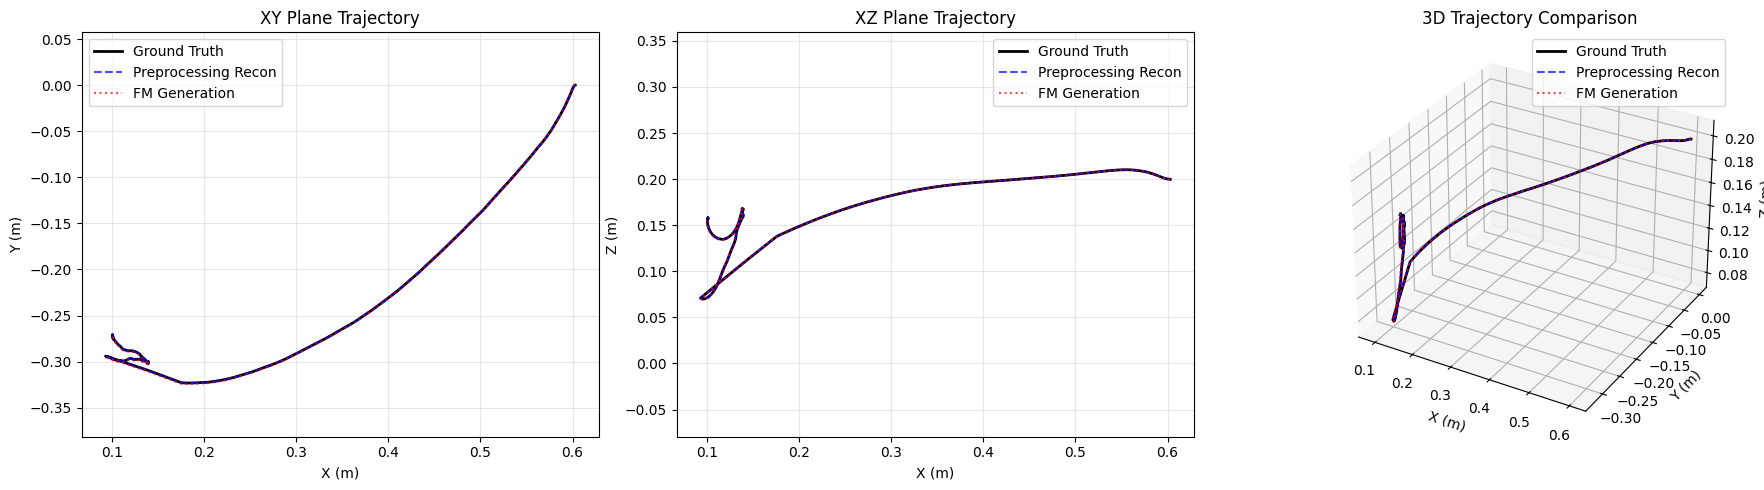

Trajectory comparison plot saved to: artifacts/pouring_overfit_single/62_fm_trajectory_comparison.png


In [75]:
# Trajectory visualization: GT vs Preprocessing Recon vs FM Generation
fig = plt.figure(figsize=(18, 5))

# XY plane
ax1 = fig.add_subplot(131)
ax1.plot(T_seq_raw[:, 0, 3], T_seq_raw[:, 1, 3], 'k-', label='Ground Truth', linewidth=2)
ax1.plot(T_recon_delta_abs[:, 0, 3], T_recon_delta_abs[:, 1, 3], 'b--', 
         label='Preprocessing Recon', linewidth=1.5, alpha=0.7)
ax1.plot(T_fm_abs[:, 0, 3], T_fm_abs[:, 1, 3], 'r:', 
         label='FM Generation', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('XY Plane Trajectory')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# XZ plane
ax2 = fig.add_subplot(132)
ax2.plot(T_seq_raw[:, 0, 3], T_seq_raw[:, 2, 3], 'k-', label='Ground Truth', linewidth=2)
ax2.plot(T_recon_delta_abs[:, 0, 3], T_recon_delta_abs[:, 2, 3], 'b--', 
         label='Preprocessing Recon', linewidth=1.5, alpha=0.7)
ax2.plot(T_fm_abs[:, 0, 3], T_fm_abs[:, 2, 3], 'r:', 
         label='FM Generation', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_title('XZ Plane Trajectory')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# 3D trajectory
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(T_seq_raw[:, 0, 3], T_seq_raw[:, 1, 3], T_seq_raw[:, 2, 3], 
         'k-', label='Ground Truth', linewidth=2)
ax3.plot(T_recon_delta_abs[:, 0, 3], T_recon_delta_abs[:, 1, 3], T_recon_delta_abs[:, 2, 3], 
         'b--', label='Preprocessing Recon', linewidth=1.5, alpha=0.7)
ax3.plot(T_fm_abs[:, 0, 3], T_fm_abs[:, 1, 3], T_fm_abs[:, 2, 3], 
         'r:', label='FM Generation', linewidth=1.5, alpha=0.7)
ax3.set_xlabel('X (m)')
ax3.set_ylabel('Y (m)')
ax3.set_zlabel('Z (m)')
ax3.set_title('3D Trajectory Comparison')
ax3.legend()

plt.tight_layout()
#plt.savefig(artifacts_dir / '62_fm_trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Trajectory comparison plot saved to: {artifacts_dir / '62_fm_trajectory_comparison.png'}")

## 17. 实验总结

In [76]:
print("="*80)
print("Flow Matching Overfitting Experiment Summary")
print("="*80)

print("\n✓ Sweep Experiment:")
print(f"  - Total configs: {len(sweep_configs)}")
print(f"  - Best config: {best_overall_config['name']}")
print(f"  - Best loss: {best_overall_loss:.6f}")

print("\n✓ Generation Quality (vs Ground Truth):")
print(f"  - Rotation error: {metrics_fm['rotation']['mean_deg']:.2f}° (mean), "
      f"{metrics_fm['rotation']['max_deg']:.2f}° (max)")
print(f"  - Translation error: {metrics_fm['translation']['mean_m']*100:.2f} cm (mean), "
      f"{metrics_fm['translation']['max_m']*100:.2f} cm (max)")

print("\n✓ Comparison Analysis:")
print(f"  Preprocessing Recon vs FM Generation:")
print(f"    Rotation: {metrics_delta['rotation']['mean_deg']:.2e}° vs {metrics_fm['rotation']['mean_deg']:.2f}°")
print(f"    Translation: {metrics_delta['translation']['mean_m']*100:.2e} cm vs {metrics_fm['translation']['mean_m']*100:.2f} cm")

print("\n✓ Output Files:")
for f in sorted(artifacts_dir.glob('*')):
    if any(x in f.name for x in ['fm_', 'sweep_', '6']):
        print(f"  - {f.name}")

print("\n" + "="*80)
print("Experiment Completed!")
print("="*80)

Flow Matching Overfitting Experiment Summary

✓ Sweep Experiment:
  - Total configs: 2
  - Best config: h256_l4_cosine_upgraded
  - Best loss: 0.079240

✓ Generation Quality (vs Ground Truth):
  - Rotation error: 0.14° (mean), 0.27° (max)
  - Translation error: 0.11 cm (mean), 0.14 cm (max)

✓ Comparison Analysis:
  Preprocessing Recon vs FM Generation:
    Rotation: 9.10e-03° vs 0.14°
    Translation: 2.72e-05 cm vs 0.11 cm

✓ Output Files:
  - 23_fm_delta_T_seq.npz
  - 60_sweep_results.png
  - 61_fm_vs_recon_comparison.png
  - fm_delta_best.pt
  - sweep_results.json

Experiment Completed!


---

## 实验结论

### 预处理管线验证
- ✓ 两种方法的预处理-重构管线均已验证
- ✓ 数值误差在机器精度范围内
- ✓ 可视化确认轨迹重构正确

### Flow Matching 训练（待完成）
- [ ] 方法1 (R9+t3) 过拟合训练
- [ ] 方法2 (ΔSE(3)) 过拟合训练
- [ ] 两种方法的生成质量对比
- [ ] 选择最优方法用于后续实验

### 下一步
1. 完成Flow Matching训练代码
2. 评估过拟合效果
3. 扩展到多样本训练
4. 集成到完整的倒水任务管线